In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    pd,
    plt,
    save_figure,
    load_file,
    list_runs,
    FIGURE_SIZE,
    LINE_STYLE,
    GRID_STYLE,
    REFERENCE_LINE_STYLE,
    THEORY_LINE_STYLE,
    bordeaux,
    navy,
)
from analysis import align_to_rounds

FIG_DIR = "../figures/evaluation/stressors"
os.makedirs(FIG_DIR, exist_ok=True)

metrics_path = "../metrics/"


def per_run_round_acc(path):
    df = load_file(path)

    round_rows = df[df.field == "current_round"][["timestamp", "node", "value"]].copy()
    round_rows["cr"] = pd.to_numeric(round_rows.value, errors="coerce")

    acc_rows = df[df.field == "aggregated_accuracy"][["timestamp", "node", "value"]].copy()
    acc_rows["acc"] = pd.to_numeric(acc_rows.value, errors="coerce")

    merged = align_to_rounds(acc_rows, round_rows[["timestamp", "node", "cr"]]).dropna(subset=["cr", "acc"])

    # I keep the last non-zero accuracy reported per node per round.
    nonzero = merged[merged["acc"] > 0]
    return nonzero.groupby(["node", "cr"])["acc"].last().reset_index()


def load_attack_corpus(base_dir):
    rows = []

    for name, path in list_runs(base_dir):

        # Run names start with the aggregator, e.g. "krum_label_flip_b04_seed_0".
        if name.startswith("fedavg_"):
            aggregator = "fedavg"
        elif name.startswith("krum_"):
            aggregator = "krum"
        else:
            continue

        # Strip the aggregator prefix.
        rest = name[len(aggregator) + 1:]
        head, sep, seed = rest.rpartition("_seed_")
        if sep and seed.isdigit():
            rest = head

        # Strip the Byzantine-count suffix "_b<NN>".
        n_byz = 0
        head, sep, b = rest.rpartition("_b")
        if sep and b.isdigit() and len(b) == 2:
            rest, n_byz = head, int(b)

        if rest not in ("clean", "label_flip", "gaussian_noise", "sign_flip"):
            continue
        attack = rest

        round_acc = per_run_round_acc(path)
        per_round = round_acc.groupby("cr")["acc"].mean().reset_index()
        per_round = per_round[per_round["cr"] <= 10]

        for _, r in per_round.iterrows():
            rows.append((aggregator, attack, n_byz, int(r["cr"]), float(r["acc"])))

    return pd.DataFrame(rows, columns=["aggregator", "attack", "n_byz", "round", "acc"])


df_atk = load_attack_corpus(os.path.join(metrics_path, "b2_attack_robustness"))

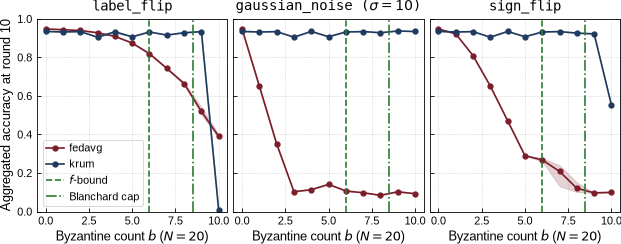

In [2]:
N_FULL = 20
ATTACK_FINAL_ROUND = 10
F_BOUND = 6
BLANCHARD_LAST_SAFE = 8

COLOR_BY_AGG = {"fedavg": bordeaux, "krum": navy}
ATTACK_TITLES = {
    "label_flip": "label_flip",
    "gaussian_noise": r"gaussian_noise ($\sigma{=}10$)",
    "sign_flip": "sign_flip",
}


def panel_attack_curve(ax, attack, df, show_legend=False):
    final = df[df["round"] == ATTACK_FINAL_ROUND]

    for aggregator in ["fedavg", "krum"]:
        clean = final[(final.aggregator == aggregator) & (final.attack == "clean")]
        attack_sub = final[(final.aggregator == aggregator) & (final.attack == attack)]

        # Point at zero Byzantine nodes is the clean baseline; then one point
        # per Byzantine count, carrying mean accuracy plus min/max for the band.
        points = []
        points.append((0, clean["acc"].mean(), clean["acc"].min(), clean["acc"].max()))
        for n_byz, group in attack_sub.groupby("n_byz"):
            points.append((int(n_byz), group["acc"].mean(), group["acc"].min(), group["acc"].max()))

        series = pd.DataFrame(points, columns=["n_byz", "acc", "lo", "hi"]).sort_values("n_byz")
        color = COLOR_BY_AGG[aggregator]

        ax.fill_between(series["n_byz"], series["lo"], series["hi"], color=color, alpha=0.2)
        ax.plot(series["n_byz"], series["acc"], color=color, marker="o", markersize=3.5, label=aggregator, **LINE_STYLE)

    ax.axvline(F_BOUND, label=r"$f$-bound", **REFERENCE_LINE_STYLE)
    ax.axvline(BLANCHARD_LAST_SAFE + 0.5, label=r"Blanchard cap", **THEORY_LINE_STYLE)

    ax.set_xlabel(r"Byzantine count $b$ ($N=20$)")
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(0, 1.0)
    ax.grid(**GRID_STYLE)

    if show_legend:
        ax.legend(loc="lower left", framealpha=0.9, ncol=1)


fig, axes = plt.subplots(1, 3, figsize=FIGURE_SIZE, sharey=True)

for ax, attack in zip(axes, ["label_flip", "gaussian_noise", "sign_flip"]):
    panel_attack_curve(ax, attack, df_atk, show_legend=(attack == "label_flip"))
    ax.set_title(ATTACK_TITLES[attack], fontfamily="monospace")

axes[0].set_ylabel("Aggregated accuracy at round 10")
plt.tight_layout()
save_figure(fig, f"{FIG_DIR}/fedavg_vs_krum_attacks.pdf")
plt.show()